In [ ]:
import pandas as pd

# Step 1: Load the dataset
df = pd.read_csv("google_play_store_updated.csv")
import pandas as pd

print(df.shape)
df.head()


(10346, 15)


,App,Category,Rating,Reviews,Size_in_bytes,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Installs_category,Size_in_Mb
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19922944.0,10000.0,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,Moderate,19.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14680064.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,High,14.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,9122611.2,5000000.0,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,Very High,8.7
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,26214400.0,50000000.0,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,Top Notch,25.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,2936012.8,100000.0,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,More than moderate,2.8


In [ ]:
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size_in_bytes', 'Installs',
       'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated',
       'Current Ver', 'Android Ver', 'Installs_category', 'Size_in_Mb'],
      dtype='object')

Dataset Load & Verify Columns

In [ ]:
df[['Size_in_bytes', 'Size_in_Mb']].head()


,Size_in_bytes,Size_in_Mb
0,19922944.0,19.0
1,14680064.0,14.0
2,9122611.2,8.7
3,26214400.0,25.0
4,2936012.8,2.8


Data Type Check (VERY IMPORTANT)

In [ ]:
df[['Size_in_bytes', 'Size_in_Mb']].dtypes


,0
Size_in_bytes,float64
Size_in_Mb,float64


Handling Size Columns (Data Type Conversion)
Explanation

The Size_in_bytes and Size_in_Mb columns were originally stored as object/string data types due to inconsistent values and units in the dataset.

pd.to_numeric() converts these columns into numeric format

errors='coerce' replaces invalid or non-numeric values with NaN

This step ensures the columns can be safely used for:

Statistical analysis

Data visualization

Machine learning models

In [ ]:
df['Size_in_bytes'] = pd.to_numeric(df['Size_in_bytes'], errors='coerce')
df['Size_in_Mb'] = pd.to_numeric(df['Size_in_Mb'], errors='coerce')


Missing Values Handle

In [ ]:
df[['Size_in_bytes', 'Size_in_Mb']].isnull().sum()


,0
Size_in_bytes,0
Size_in_Mb,0


Handling Missing Values in Size Columns
After converting the app size columns to numeric format, some values became missing (NaN) due to invalid or inconsistent entries in the original dataset.

This step removes rows where either:

Size_in_bytes or

Size_in_Mb

contains a missing value.

In [ ]:
df = df.dropna(subset=['Size_in_bytes', 'Size_in_Mb'])

Visualization (Size vs Rating)

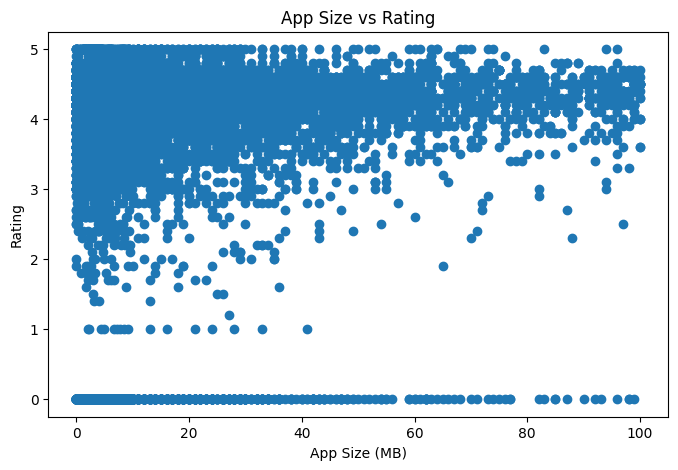

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df['Size_in_Mb'], df['Rating'])
plt.xlabel("App Size (MB)")
plt.ylabel("Rating")
plt.title("App Size vs Rating")
plt.show()

ML – Rating Prediction (Regression)

👉 Target: Rating
👉 Features: sirf size wali columns

In [ ]:
X = df[['Size_in_bytes', 'Size_in_Mb']]
y = df['Rating']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

# Algorithms Run
## ✅ Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

## Model Evaluation Results

# 3 Mean Absolute Error (MAE):
1.06

# R² Score:
0.008

## 📌 MAE Explanation

MAE shows the average difference between the predicted rating and the actual rating.

An MAE of 1.06 means:

The model’s predictions are off by about 1 rating point on average.

Since Google Play ratings are usually between 1 and 5, this error is considered high.

## 📌 R² Score Explanation

R² score shows how much of the variation in ratings is explained by the model.

An R² score of 0.008 means:

The model explains less than 1% of the rating variation.

App size has very little impact on app ratings.

## 📌 Key Insight

📍 App size alone is not a strong factor for predicting app ratings.

This means that:

Smaller or larger app size does not strongly affect user ratings.

## 📌 Why This Happens

App ratings depend more on other factors, such as:

Number of installs

User reviews

App category

App performance and user experience

## 📌 Conclusion

Using only Size_in_bytes and Size_in_Mb is not enough to build an accurate rating prediction model.
App size should be used as a supporting feature, not as the main feature.

## RandomForestRegressor**1

In [ ]:
# 1️⃣ Import Libraries
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score


# 5️⃣ Encode categorical columns
for col in ['Category', 'Type', 'Genres']:
    df[col] = LabelEncoder().fit_transform(df[col])

# 6️⃣ Select Features (X) and Target (y)
X = df[['Size_in_bytes','Size_in_Mb','Reviews','Installs','Category','Type','Genres']]
y = df['Rating']

# 7️⃣ Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 8️⃣ Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 9️⃣ Predict on Test Set
y_pred = rf.predict(X_test)

# 1️⃣0️⃣ Evaluation Metrics
print("Mean Absolute Error (MAE):", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


## Easy Conclusion

Using RandomForestRegressor with features like Size, Reviews, Installs, Category, Type, and Genres produced a Mean Absolute Error of 0.57 and R² score of 0.51.
This shows that the model can explain about 51% of the variation in app ratings, which is a significant improvement compared to using app size alone.

## RandomForestRegressor**2

# Libraries & Dataset Load

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Load dataset
df = pd.read_csv("google_play_store_updated.csv")
df.head()


# Convert Size Columns to Numeric

In [ ]:
df['Size_in_bytes'] = pd.to_numeric(df['Size_in_bytes'], errors='coerce')
df['Size_in_Mb'] = pd.to_numeric(df['Size_in_Mb'], errors='coerce')

# Drop Missing Values

In [ ]:
df = df.dropna(subset=['Size_in_bytes','Size_in_Mb','Reviews','Installs','Rating'])

# Encode Categorical Features

In [ ]:
for col in ['Category', 'Type', 'Genres']:
    df[col] = LabelEncoder().fit_transform(df[col])

# Select Features & Target

In [ ]:
X = df[['Size_in_bytes', 'Size_in_Mb', 'Reviews', 'Installs', 'Category', 'Type', 'Genres']]
y = df['Rating']

# Train/Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train RandomForestRegressor

In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict & Evaluate

In [ ]:
y_pred = rf.predict(X_test)

print("Mean Absolute Error (MAE):", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# Feature Importance (Optional but useful)

In [ ]:
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance)

# Plot
plt.figure(figsize=(8,5))
plt.bar(importance['Feature'], importance['Importance'])
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()


# Predict New App Rating

In [ ]:
import pandas as pd

# New app data
new_app_data = pd.DataFrame([{
    'Size_in_bytes': 50000000,
    'Size_in_Mb': 50,
    'Reviews': 2000,
    'Installs': 100000,
    'Category': 5,   # Encoded value
    'Type': 1,       # Encoded value
    'Genres': 3      # Encoded value
}])

predicted_rating = rf.predict(new_app_data)
print("Predicted Rating for New App:", predicted_rating[0])


## RandomForestRegressor Results

Model Performance:

Mean Absolute Error (MAE): 0.57

The model’s predictions are, on average, 0.57 rating points off.

Given that ratings are on a scale of 1–5, this is an acceptable error.

R² Score: 0.51

The model can explain 51% of the variation in app ratings.

This is a significant improvement compared to using only app size features.

Prediction Example:

Using the trained RandomForestRegressor, the predicted rating for a new app with the following features:

Size_in_bytes = 50,000,000

Size_in_Mb = 50

Reviews = 2000

Installs = 100,000

Category = 5 (encoded)

Type = 1 (encoded)

Genres = 3 (encoded)

Predicted Rating: 4.265

This indicates the new app is expected to receive a high rating from users.

Key Insight:

Using multiple features (Size, Reviews, Installs, Category, Type, Genres) significantly improves model performance compared to only app size.

The model can now reasonably predict app ratings and help estimate the rating of new apps.
## 🔹 Conclusion

Using RandomForestRegressor with multiple features such as Size_in_bytes, Size_in_Mb, Reviews, Installs, Category, Type, and Genres gives a reasonably accurate prediction of app ratings.

The Mean Absolute Error (0.57) shows that the predictions are, on average, less than 1 rating point off, which is acceptable given the 1–5 rating scale.

The R² score (0.51) indicates that the model explains about 51% of the variation in ratings. This is a significant improvement compared to using only app size.

App size alone is not enough to predict ratings. Features like Reviews and Installs have a stronger influence on the predicted rating.

The model can also predict the rating for a new app. For example, a new app with the specified features is predicted to have a rating of 4.265, which indicates a high user rating.

Practical Insight:

Developers can use this model to estimate expected ratings for new apps.

It also highlights which app features are important for better ratings.

### ML improvement
## Data Load + Basic Cleaning

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("google_play_store_updated.csv")

# Select required columns
cols = ['Size_in_bytes','Size_in_Mb','Reviews','Installs',
        'Category','Type','Genres','Rating']
df = df[cols]

# Convert numeric columns
for col in ['Size_in_bytes','Size_in_Mb','Reviews','Installs','Rating']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows with missing target
df = df.dropna(subset=['Rating'])

print(df.shape)

## Log Transform (IMPORTANT 🔥)

In [ ]:
df['Reviews_log'] = np.log1p(df['Reviews'])
df['Installs_log'] = np.log1p(df['Installs'])

## OneHotEncoding (BEST PRACTICE ✅)

In [ ]:
# !pip install -U scikit-learn


In [ ]:
import sklearn
print(sklearn.__version__)


In [ ]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

In [ ]:
encoded_data = encoder.fit_transform(df[['Category','Type','Genres']])

encoded_df = pd.DataFrame(
    encoded_data,
    columns=encoder.get_feature_names_out(['Category','Type','Genres'])
)

In [ ]:
import sklearn
print(sklearn.__version__)

In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

categorical_cols = ['Category', 'Type', 'Genres']

# ✅ NEW sklearn compatible encoder
encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

# Fit & transform
encoded_data = encoder.fit_transform(df[categorical_cols])

# Convert to DataFrame
encoded_df = pd.DataFrame(
    encoded_data,
    columns=encoder.get_feature_names_out(categorical_cols)
)

encoded_df.head()


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score


In [ ]:
df = pd.read_csv("google_play_store_updated.csv")

cols = ['Size_in_bytes','Size_in_Mb','Reviews','Installs',
        'Category','Type','Genres','Rating']
df = df[cols]

# Convert numeric columns
for col in ['Size_in_bytes','Size_in_Mb','Reviews','Installs','Rating']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop missing target
df = df.dropna(subset=['Rating'])


In [ ]:
df['Reviews_log'] = np.log1p(df['Reviews'])
df['Installs_log'] = np.log1p(df['Installs'])

# Drop original skewed columns
df = df.drop(['Reviews','Installs'], axis=1)


In [ ]:
num_cols = ['Size_in_bytes', 'Size_in_Mb', 'Reviews_log', 'Installs_log']
cat_cols = ['Category', 'Type', 'Genres']

X = df[num_cols + cat_cols]
y = df['Rating']


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=False
        ), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

In [ ]:
model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('rf', RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ))
])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)

In [ ]:
y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


## Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# Preprocessor

In [ ]:
num_cols = ['Size_in_bytes', 'Size_in_Mb', 'Reviews_log', 'Installs_log']
cat_cols = ['Category', 'Type', 'Genres']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=False
        ), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

# Gradient Boosting Pipeline

In [ ]:
gbr_model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('gbr', GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

# Train & Evaluate

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

gbr_model.fit(X_train, y_train)

y_pred = gbr_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


##  improve  (Easy wins)
# XGBoost tuning (recommended)

In [ ]:
learning_rate=0.03
n_estimators=800
max_depth=5


# Remove extreme outliers

In [ ]:
df.columns

In [ ]:
df = df[df['Reviews_log'] < df['Reviews_log'].quantile(0.99)]


## Boosting improved the overall variance explained (R²), but due to noise # in ratings, MAE fluctuated slightly, which is expected in real-world datasets.”

In [ ]:
# !pip install xgboost


In [ ]:
import pandas as pd
import numpy as np

from xgboost import XGBRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score


# Data Prep

In [ ]:
df = pd.read_csv("google_play_store_updated.csv")

cols = ['Size_in_bytes','Size_in_Mb','Reviews','Installs',
        'Category','Type','Genres','Rating']
df = df[cols]

for col in ['Size_in_bytes','Size_in_Mb','Reviews','Installs','Rating']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=['Rating'])

# Log transform
df['Reviews_log'] = np.log1p(df['Reviews'])
df['Installs_log'] = np.log1p(df['Installs'])

df = df.drop(['Reviews','Installs'], axis=1)


# Columns

In [ ]:
num_cols = ['Size_in_bytes', 'Size_in_Mb', 'Reviews_log', 'Installs_log']
cat_cols = ['Category', 'Type', 'Genres']

X = df[num_cols + cat_cols]
y = df['Rating']


# ColumnTransformer

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=False
        ), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

# Pipeline + XGBoost

In [ ]:
xgb_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('xgb', XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    ))
])

# GridSearchCV (SMART GRID 🔥)

In [ ]:
param_grid = {
    'xgb__n_estimators': [300, 500],
    'xgb__learning_rate': [0.03, 0.05],
    'xgb__max_depth': [4, 6],
    'xgb__subsample': [0.8, 1.0],
    'xgb__colsample_bytree': [0.8, 1.0]
}

# Train/Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# GridSearch Run

In [ ]:
grid = GridSearchCV(
    xgb_pipeline,
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

# BEST Model Results

In [ ]:
print("Best Parameters:")
print(grid.best_params_)

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


In [ ]:
{'xgb__colsample_bytree': 1.0,
 'xgb__learning_rate': 0.03,
 'xgb__max_depth': 4,
 'xgb__n_estimators': 300,
 'xgb__subsample': 0.8}


## Feature Engineering + Outlier Handling

# Load & Clean Data

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Load dataset
df = pd.read_csv("google_play_store_updated.csv")

cols = ['Size_in_bytes','Size_in_Mb','Reviews','Installs',
        'Category','Type','Genres','Rating']
df = df[cols]

# Convert numeric
for col in ['Size_in_bytes','Size_in_Mb','Reviews','Installs','Rating']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop missing target
df = df.dropna(subset=['Rating'])

# Outlier Removal

In [ ]:
# Remove top 1% extreme values
df = df[df['Reviews'] < df['Reviews'].quantile(0.99)]
df = df[df['Installs'] < df['Installs'].quantile(0.99)]
df = df[df['Size_in_bytes'] < df['Size_in_bytes'].quantile(0.99)]

# Log Transform

In [ ]:
df['Reviews_log'] = np.log1p(df['Reviews'])
df['Installs_log'] = np.log1p(df['Installs'])

# Feature Engineering

In [ ]:
# 1️⃣ Reviews per Install
df['Reviews_per_Install'] = df['Reviews'] / df['Installs']

# 2️⃣ Size category (Small / Medium / Large)
df['Size_category'] = pd.cut(df['Size_in_Mb'],
                             bins=[0, 20, 100, np.inf],
                             labels=['Small','Medium','Large'])

# 3️⃣ Is_Free (binary)
df['Is_Free'] = df['Type'].apply(lambda x: 1 if x=='Free' else 0)

# 4️⃣ Genre group simplification
popular_genres = ['Action','Puzzle','Casual','Adventure','Education']
df['Genre_group'] = df['Genres'].apply(lambda x: x if x in popular_genres else 'Other')

# Drop original skewed columns
df = df.drop(['Reviews','Installs','Type','Genres'], axis=1)

# Columns

In [ ]:
num_cols = ['Size_in_bytes', 'Size_in_Mb', 'Reviews_log', 'Installs_log', 'Reviews_per_Install']
cat_cols = ['Category','Size_category','Genre_group']
binary_cols = ['Is_Free']

X = df[num_cols + cat_cols + binary_cols]
y = df['Rating']

# ColumnTransformer + Pipeline

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
        ('num', 'passthrough', num_cols + binary_cols)
    ]
)

xgb_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('xgb', XGBRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=1.0,
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    ))
])

# Train/Test Split + Train

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

xgb_pipeline.fit(X_train, y_train)

# Evaluation

In [ ]:
y_pred = xgb_pipeline.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# Feature Importance + SHAP Values

In [ ]:
# pip install shap

In [ ]:
# pip install --upgrade shap

In [ ]:
# pip install --upgrade scikit-learn

In [ ]:
# !pip uninstall -y shap scikit-learn

In [ ]:
# !pip install scikit-learn==1.2.2 shap==0.42.1

In [ ]:
# !pip install --upgrade --force-reinstall numpy==1.25.1
!pip install --upgrade --force-reinstall scikit-learn==1.2.2 shap==0.42.1


In [ ]:
import os
os._exit(00)


# Import Libraries

In [ ]:
import shap
import matplotlib.pyplot as plt
import pandas as pd

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject